# Blood Donation Prediction Project
Capstone ID: PRCP-1011

This notebook includes:
- Data Analysis Report
- Predictive Modeling
- Model Comparison Report
- Challenges Faced Report

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Dataset
df = pd.read_csv(r"C:\Users\aysha\Capstone_Projects\data\Data\Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.rename(columns={
    'Months since Last Donation': 'Last_Donation',
    'Number of Donations': 'Donations',
    'Total Volume Donated (c.c.)': 'Volume',
    'Months since First Donation': 'First_Donation',
    'Made Donation in March 2007': 'Target'
}, inplace=True)
df.head()

,Last_Donation,Donations,Volume,First_Donation,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Last_Donation   576 non-null    int64
 1   Donations       576 non-null    int64
 2   Volume          576 non-null    int64
 3   First_Donation  576 non-null    int64
 4   Target          576 non-null    int64
dtypes: int64(5)
memory usage: 22.6 KB
None
       Last_Donation   Donations        Volume  First_Donation      Target
count     576.000000  576.000000    576.000000      576.000000  576.000000
mean        9.439236    5.427083   1356.770833       34.050347    0.239583
std         8.175454    5.740010   1435.002556       24.227672    0.427200
min         0.000000    1.000000    250.000000        2.000000    0.000000
25%         2.000000    2.000000    500.000000       16.000000    0.000000
50%         7.000000    4.000000   1000.000000       28.000000    0.000000
75%        14.000000    7.

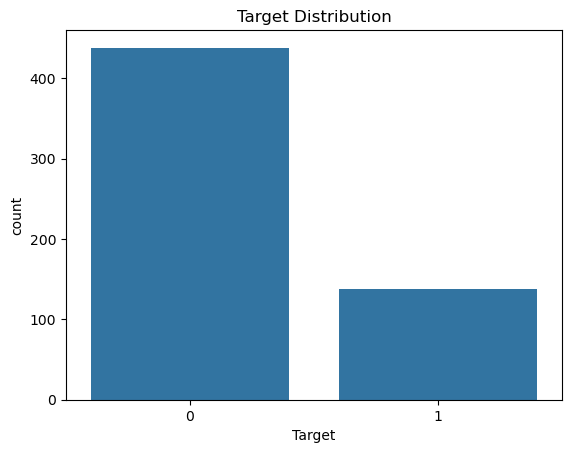

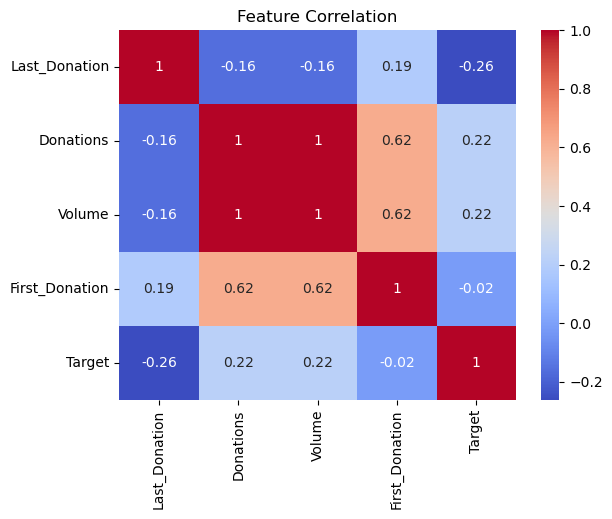

In [4]:
# Data Analysis
print(df.info())
print(df.describe())
print(df.isnull().sum())

sns.countplot(x='Target', data=df)
plt.title('Target Distribution')
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [5]:
# Modeling
X = df.drop('Target', axis=1)
y = df['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'Report': classification_report(y_test, y_pred, output_dict=True)
    }

In [6]:
# Model Comparison
pd.DataFrame({
    k: {'Accuracy': round(v['Accuracy'], 4), 'ROC AUC': round(v['ROC AUC'], 4)}
    for k, v in results.items()
}).T

,Accuracy,ROC AUC
Logistic Regression,0.7586,0.7854
Random Forest,0.7241,0.7362
SVM,0.7586,0.7727
Naive Bayes,0.7500,0.7521
KNN,0.7672,0.7711


In [7]:
# Best Model Selection
best = max(results.items(), key=lambda x: x[1]['ROC AUC'])
print(f"Best Model: {best[0]} with ROC AUC: {best[1]['ROC AUC']:.4f}")

Best Model: Logistic Regression with ROC AUC: 0.7854


### Challenges Faced

- Redundant features: 'Volume' was a multiple of 'Donations'.
- Slightly imbalanced classes.
- Need for scaling due to differing feature ranges.
- Selecting appropriate evaluation metric (ROC AUC over Accuracy).
- Testing multiple models to finalize the best-performing one.